In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import os
import warnings

# Fix KMeans MKL warning (Windows issue)
os.environ["OMP_NUM_THREADS"] = "1"

# Suppress non-critical warnings
warnings.filterwarnings("ignore")

In [14]:
data = pd.read_excel("customer_segmentation_dataset.xlsx")

In [15]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,33,132,67
1,2,Female,38,56,84
2,3,Male,67,40,52
3,4,Male,62,42,10
4,5,Male,51,62,51


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [17]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,45.275000,78.415000,48.750000
std,57.879185,15.852948,39.012854,27.430451
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,32.000000,43.500000,25.000000
50%,100.500000,47.500000,78.500000,51.000000
75%,150.250000,59.000000,111.000000,71.000000
max,200.000000,70.000000,150.000000,99.000000


In [18]:
#Converting gender to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Gender']=le.fit_transform(data['Gender'])

In [19]:
#select features
x = data[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

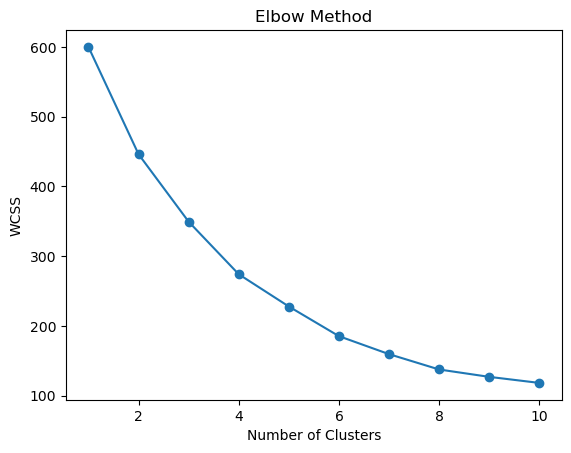

In [22]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, n_init=10, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [23]:
#Applying KMeans
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)
data['Cluster'] = kmeans.fit_predict(x_scaled)

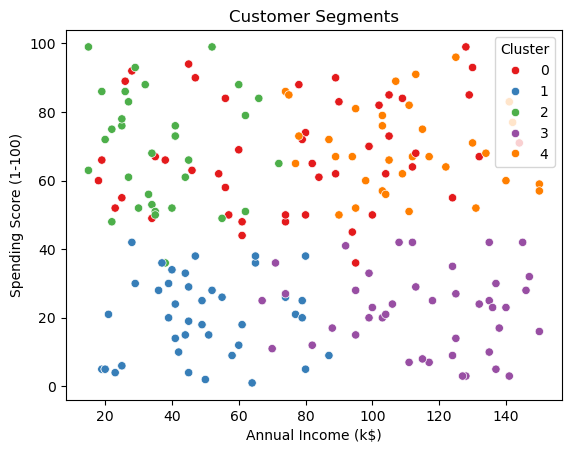

In [24]:
#Visualization
plt.figure()
sns.scatterplot(
    x=data['Annual Income (k$)'],
    y=data['Spending Score (1-100)'],
    hue=data['Cluster'],
    palette='Set1'
)
plt.title("Customer Segments")
plt.show()

In [25]:
#Analysis
data.groupby('Cluster').mean()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,104.021277,0.404255,27.829787,76.872340,67.872340
1,100.452381,0.523810,41.928571,48.333333,19.761905
2,98.636364,0.545455,56.696970,37.090909,69.393939
3,101.285714,0.404762,49.690476,115.380952,22.000000
4,96.750000,0.555556,56.333333,110.277778,69.888889


In [26]:
#Saving Output
data.to_excel("final_output.xlsx", index=False)